
NOTEBOOK 1: Exploratory Data Analysis
Bridge Digital Twin Dataset

This notebook covers:
- Data loading and basic statistics
- Missing values analysis
- Feature distributions
- Correlation analysis
- Time series patterns
- Health index evolution

Saved outputs:
- data/processed/eda_summary.csv
- outputs/eda_*.png


In [1]:
# Import data exploration Liberaries:

import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from src.utils import load_data, print_section
from src.config import *

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette(COLOR_PALETTE)


In [2]:
# ===================================================
# 1. LOAD DATA:
# ===================================================

print_section("Loading Data")


  Loading Data


In [3]:
# Load dataset

bridge_df = load_data(os.path.join(RAW_DATA_DIR, 'bridge_digital_twin_dataset.csv'))

print(f"Dataset shape:{bridge_df.shape}")
print(f"Time range: {bridge_df['Timestamp'].min()} to {bridge_df['Timestamp'].max()}")
print(f"Duration: {(bridge_df['Timestamp'].max() - bridge_df['Timestamp'].min())}")
print(f"\nColumns : {bridge_df.columns.tolist()}")

Dataset shape:(43200, 54)
Time range: 2023-01-01 00:00:00 to 2023-01-30 23:59:00
Duration: 29 days 23:59:00

Columns : ['Timestamp', 'Strain_microstrain', 'Deflection_mm', 'Vibration_ms2', 'Tilt_deg', 'Displacement_mm', 'Crack_Propagation_mm', 'Corrosion_Level_percent', 'Cable_Member_Tension_kN', 'Bearing_Joint_Forces_kN', 'Fatigue_Accumulation_au', 'Modal_Frequency_Hz', 'Temperature_C', 'Humidity_percent', 'Wind_Speed_ms', 'Wind_Direction_deg', 'Precipitation_mmh', 'Water_Level_m', 'Seismic_Activity_ms2', 'Solar_Radiation_Wm2', 'Air_Quality_Index_AQI', 'Soil_Settlement_mm', 'Vehicle_Load_tons', 'Traffic_Volume_vph', 'Pedestrian_Load_pph', 'Impact_Events_g', 'Dynamic_Load_Distribution_percent', 'Axle_Counts_pmin', 'Structural_Health_Index_SHI', 'Anomaly_Detection_Score', 'Energy_Dissipation_au', 'Acoustic_Emissions_levels', 'Visual_Analysis_Defect_Score', 'Electrical_Resistance_ohms', 'Bridge_Mood_Meter', 'Localized_Strain_Hotspot', 'Vibration_Anomaly_Location', 'SHI_Predicted_24h_Ahea

In [4]:
# ============================================
# 2. BASIC STATISTICS
# ============================================
print_section("Basic Statistics")


  Basic Statistics


In [5]:
bridge_df.describe().T

,count,mean,min,25%,50%,75%,max,std
Timestamp,43200,2023-01-15 23:59:30,2023-01-01 00:00:00,2023-01-08 11:59:45,2023-01-15 23:59:30,2023-01-23 11:59:15,2023-01-30 23:59:00,NaN
Strain_microstrain,41379.0,851.950836,363.529753,618.866446,734.476653,1072.66168,4074.893156,351.90831
Deflection_mm,41467.0,15.145403,6.889697,12.447132,14.98616,17.090508,30.38908,3.824032
Vibration_ms2,41478.0,1.339495,0.637735,1.00003,1.198123,1.532924,15.08648,0.979641
Tilt_deg,41447.0,0.756122,0.476074,0.667321,0.724295,0.832503,1.522738,0.142167
Displacement_mm,41473.0,22.703596,18.964441,21.387484,22.361439,23.985103,27.630262,1.627841
Crack_Propagation_mm,41494.0,0.015036,-0.001531,0.007511,0.015024,0.022526,0.519706,0.009338
Corrosion_Level_percent,41531.0,0.14995,-0.010256,0.074979,0.150101,0.224839,0.312679,0.086731
Cable_Member_Tension_kN,41459.0,476.054924,334.045442,396.924817,447.899673,556.36281,844.862138,91.773467
Bearing_Joint_Forces_kN,41515.0,276.967988,205.758025,237.447819,260.075977,318.127839,423.909686,45.59084


In [6]:
# Save summary statistics
bridge_df.describe().T.to_csv(os.path.join(PROCESSED_DATA_DIR, 'eda_summary.csv'))
print(f"\n✓ Saved: data/processed/eda_summary.csv")


✓ Saved: data/processed/eda_summary.csv


In [7]:
# ============================================
# 3. MISSING VALUES
# ============================================
print_section("Missing Values Analysis")


  Missing Values Analysis


In [8]:
missing = bridge_df.isnull().sum()
missing_pct = (missing / len(bridge_df)) * 100

missing_df = pd.DataFrame({
    'Missing_count': missing,
    'Missing_percentage':missing_pct.round(2)
}).sort_values('Missing_count',ascending=False)

print(missing_df[missing_df['Missing_count'] > 0])

                                       Missing_count  Missing_percentage
Vibration_Anomaly_Location                     34155               79.06
Strain_microstrain                              1821                4.22
Humidity_percent                                1783                4.13
Estimated_Repair_Cost_USD_incremental           1771                4.10
Wind_Direction_deg                              1768                4.09
Landslide_Ground_Movement                       1765                4.09
Abnormal_Traffic_Load_Surges                    1763                4.08
High_Winds_Storms                               1758                4.07
Vehicle_Load_tons                               1756                4.06
Localized_Strain_Hotspot                        1754                4.06
Tilt_deg                                        1753                4.06
Soil_Saturation_percent                         1747                4.04
Electrical_Resistance_ohms                      174

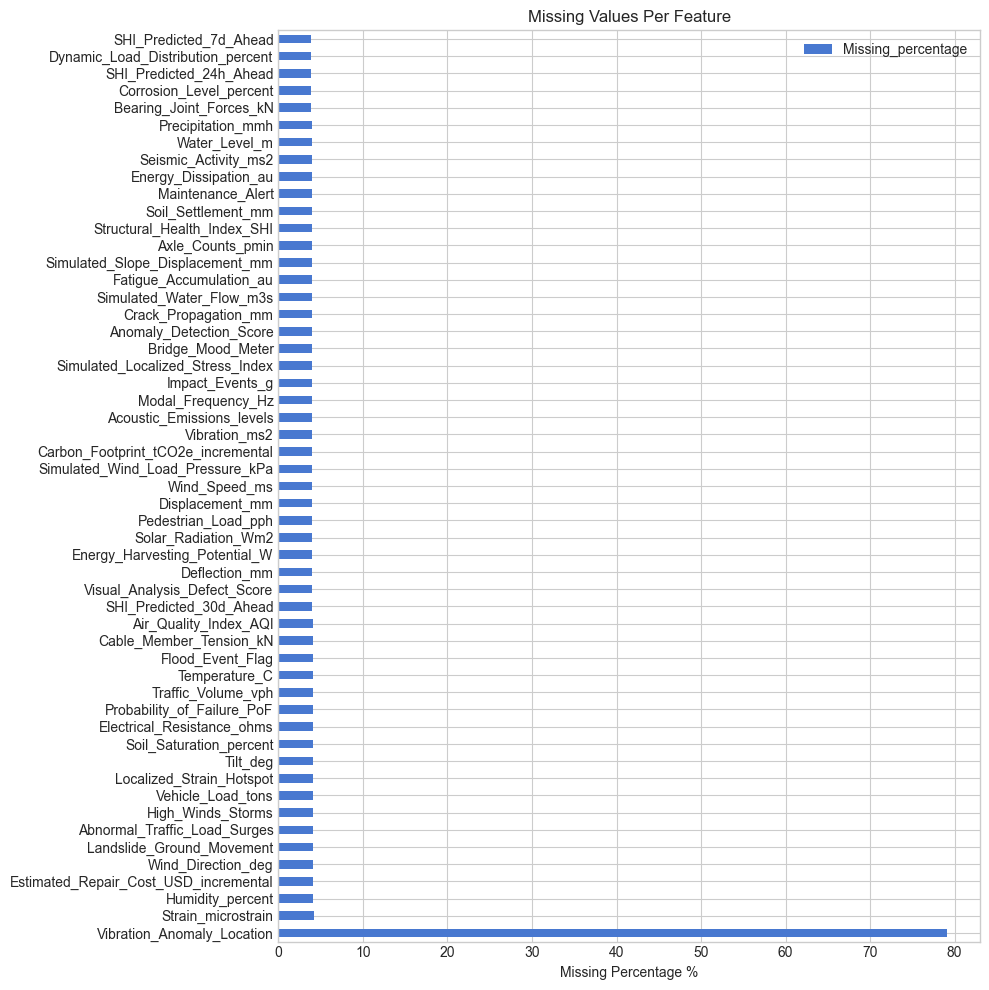

In [9]:
fig , ax = plt.subplots(figsize = (10,10))

missing_df[missing_df['Missing_count'] > 0].plot(
    kind = 'barh',
    y = 'Missing_percentage',
    ax = ax,
    color = sns.color_palette("muted")[0]
)

plt.xlabel('Missing Percentage %')
plt.title('Missing Values Per Feature')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'eda_missing_values.png'), dpi=FIGURE_DPI)
plt.show()

In [10]:
# ============================================
# 4. TARGET VARIABLE DISTRIBUTION
# ============================================
print_section("Target Variable: Structural Health Index")


  Target Variable: Structural Health Index


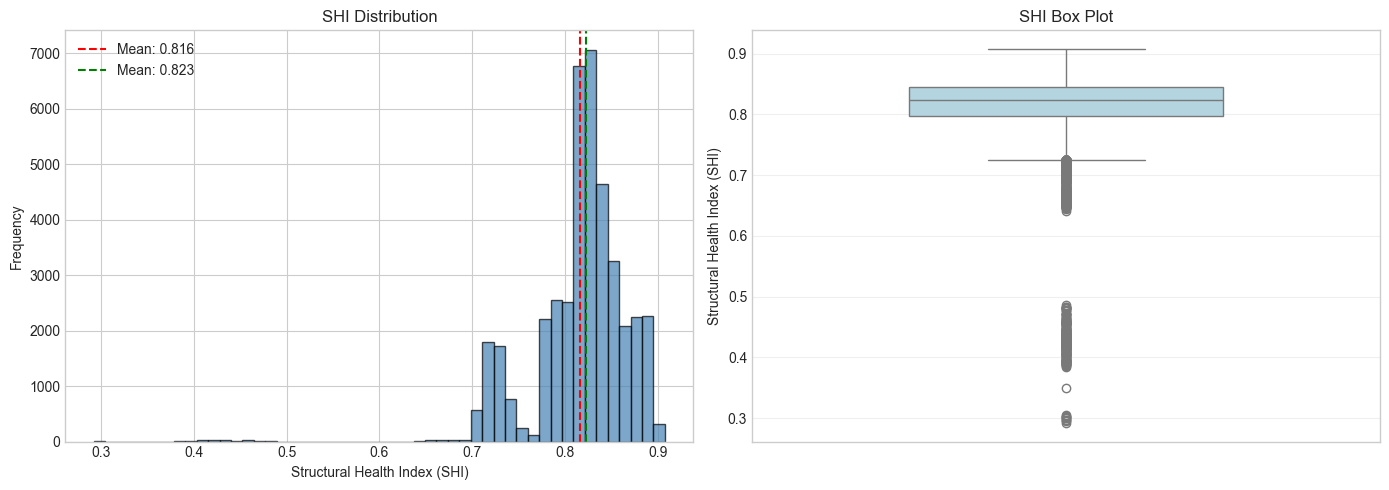


SHI Summary Statistics:
  Mean:   0.8159
  Median: 0.8229
  Std:    0.0528
  Min:    0.2921
  Max:    0.9077
  Q1:     0.7971
  Q3:     0.8455



In [11]:
fig , axes = plt.subplots(1,2, figsize = (14,5))

# Histogram
axes[0].hist(bridge_df[TARGET_COL], bins = 50, color = 'steelblue', edgecolor = 'black', alpha = 0.7)
axes[0].set_xlabel('Structural Health Index (SHI)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('SHI Distribution')
axes[0].axvline(bridge_df[TARGET_COL].mean(), color = 'red', linestyle = '--', label = f'Mean: {bridge_df[TARGET_COL].mean():.3f}')
axes[0].axvline(bridge_df[TARGET_COL].median(), color = 'green', linestyle = '--', label = f'Mean: {bridge_df[TARGET_COL].median():.3f}')
axes[0].legend()

# Box plot
sns.boxplot(y=bridge_df[TARGET_COL], ax=axes[1], color='lightblue', width=0.5)
axes[1].set_ylabel('Structural Health Index (SHI)')
axes[1].set_title('SHI Box Plot')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'eda_shi_distribution.png'), dpi=FIGURE_DPI, bbox_inches='tight')
plt.show()

print(f"\n{'='*50}")
print(f"SHI Summary Statistics:")
print(f"{'='*50}")
print(f"  Mean:   {bridge_df[TARGET_COL].mean():.4f}")
print(f"  Median: {bridge_df[TARGET_COL].median():.4f}")
print(f"  Std:    {bridge_df[TARGET_COL].std():.4f}")
print(f"  Min:    {bridge_df[TARGET_COL].min():.4f}")
print(f"  Max:    {bridge_df[TARGET_COL].max():.4f}")
print(f"  Q1:     {bridge_df[TARGET_COL].quantile(0.25):.4f}")
print(f"  Q3:     {bridge_df[TARGET_COL].quantile(0.75):.4f}")
print(f"{'='*50}\n")


  Feature Distributions


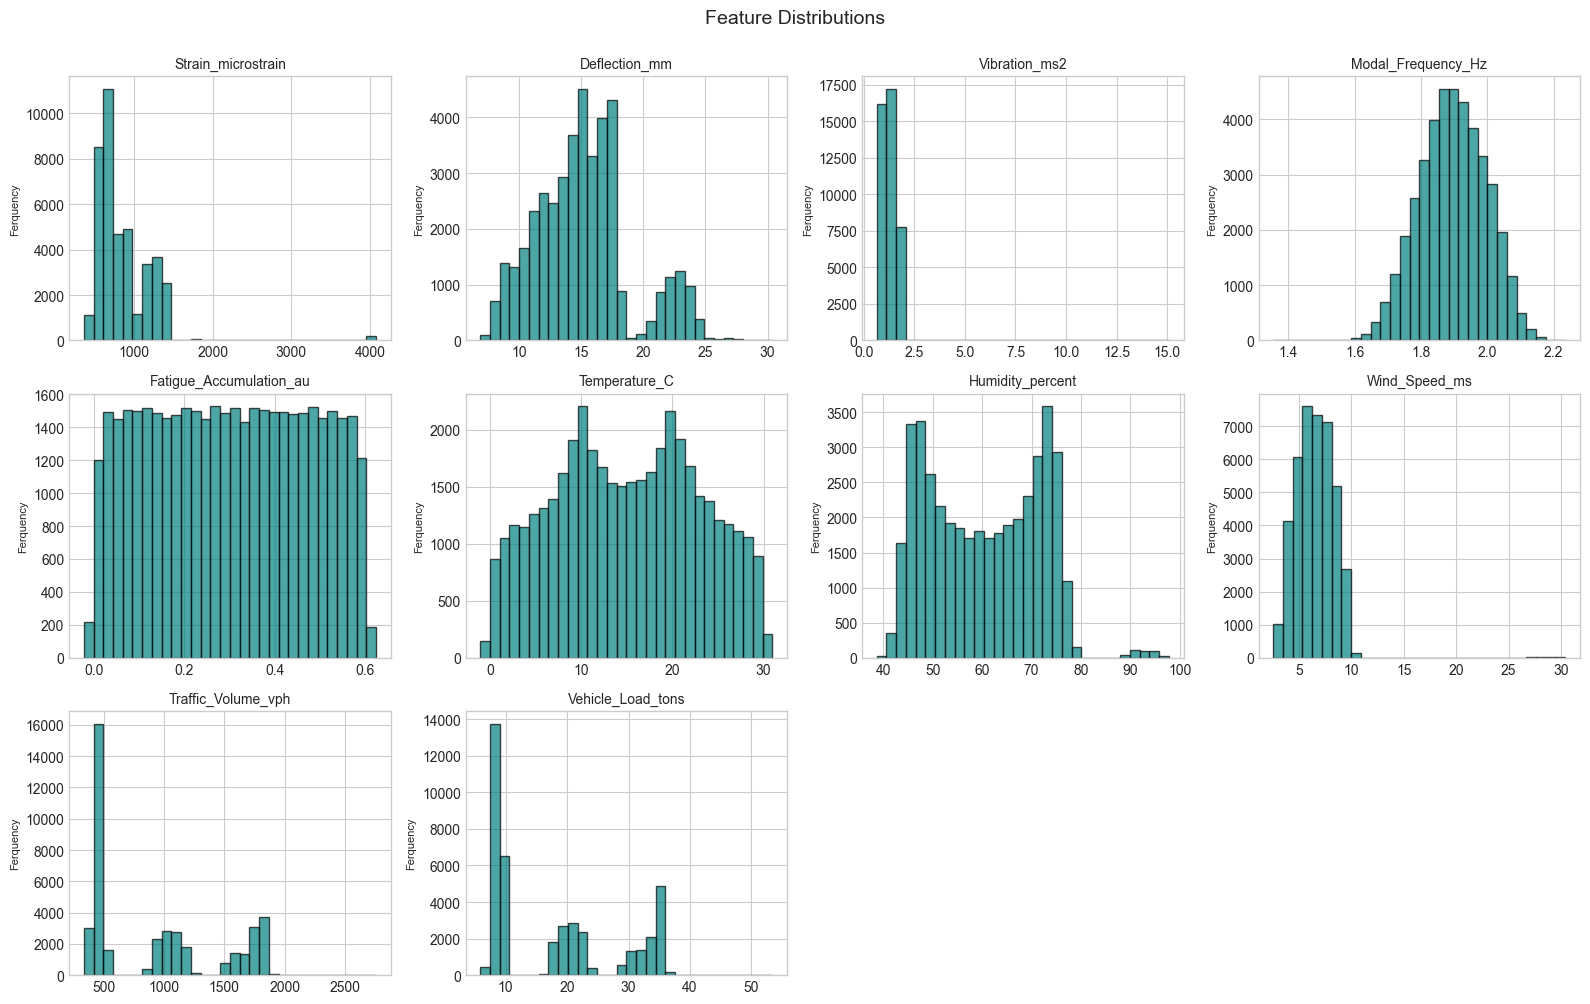

In [12]:
# ============================================
# 5. FEATURE DISTRIBUTIONS
# ============================================
print_section("Feature Distributions")



# Plot distributions for key features:

fig, axes = plt.subplots(3,4, figsize = (16, 10))
axes = axes.flatten()

for idx , col in enumerate(FEATURE_COLS):
    axes[idx].hist(bridge_df[col], bins = 30, color = 'teal', alpha = 0.7, edgecolor = 'black')
    axes[idx].set_title(col, fontsize = 10)
    axes[idx].set_xlabel('')
    axes[idx].set_ylabel('Ferquency', fontsize = 8)

for idx in range(len(FEATURE_COLS), len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle('Feature Distributions', fontsize = 14, y = 1.00)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'eda_feature_distributions.png'), dpi =FIGURE_DPI)
plt.show()

In [13]:
# Bridge structural health monitoring - Distribution insights

# STRAIN is heavily skewed right with a long tail
# Most bridges have low strain (<1000), but some spike to 4000+
# The outliers are real - they represent damaged/stressed structures

# DEFLECTION follows a normal-ish distribution
# Centered around 15-18mm, fairly symmetric
# Good sign - no weird bimodal patterns or heavy skew
# Can be used as-is without transformation

# VIBRATION has a sharp spike at the low end
# Massive peak around 0-2.5, then drops off fast
# Suggests most readings are "quiet", occasional spikes when something's wrong
# The spike might mask patterns - consider log transform or binning

# MODAL FREQUENCY is clearly normal/gaussian
# Nice bell curve centered around 1.8-1.9 Hz
# No outliers, no skew, behaves perfectly

# FATIGUE ACCUMULATION is the flattest distribution we have
# Every single bar is basically the same height (0.3 to 0.6 range)
# This is a red flag - it's either constant or measured poorly
# Very low variance = almost no predictive power

# TEMPERATURE is genuinely bimodal, two clear peaks
# One around 8-10°C (winter), one around 22-25°C (summer)
# This is real seasonal variation, not measurement error
# Strong candidate for adding season as a categorical feature

# HUMIDITY inverts with temperature (inverse correlation makes sense)
# Peak around 50% in summer, peaks around 70-80% in winter
# Probably correlated with each other in ways a model won't like
# Consider dropping one or creating a seasonal encoding instead

# WIND SPEED is right-skewed with most days calm
# Huge concentration near 5 m/s, long tail up to 30 m/s
# Most data points in calm conditions, few capture storms
# Class imbalance here - storm impacts might be underrepresented

# TRAFFIC VOLUME has a massive spike at zero
# Like 16,000 observations at 0 vehicles/hour - that's weird
# Either night-time recordings, data errors, or sensor failures
# Investigate: are these real zeroes or missing data disguised as zeroes?

# VEHICLE LOAD shows the same spike at zero
# Perfectly mirrors traffic volume (because they're the same thing)
# Confirms they're redundant - drop one without hesitation
# The multi-modal pattern (spikes at 10, 20, 30 tons) suggests discrete truck weights

# The outliers matter here
# Strain goes to 4000+, deflection to 25+, traffic to 2500+
# These aren't errors - they're the bridges actually failing



  Correlation Analysis


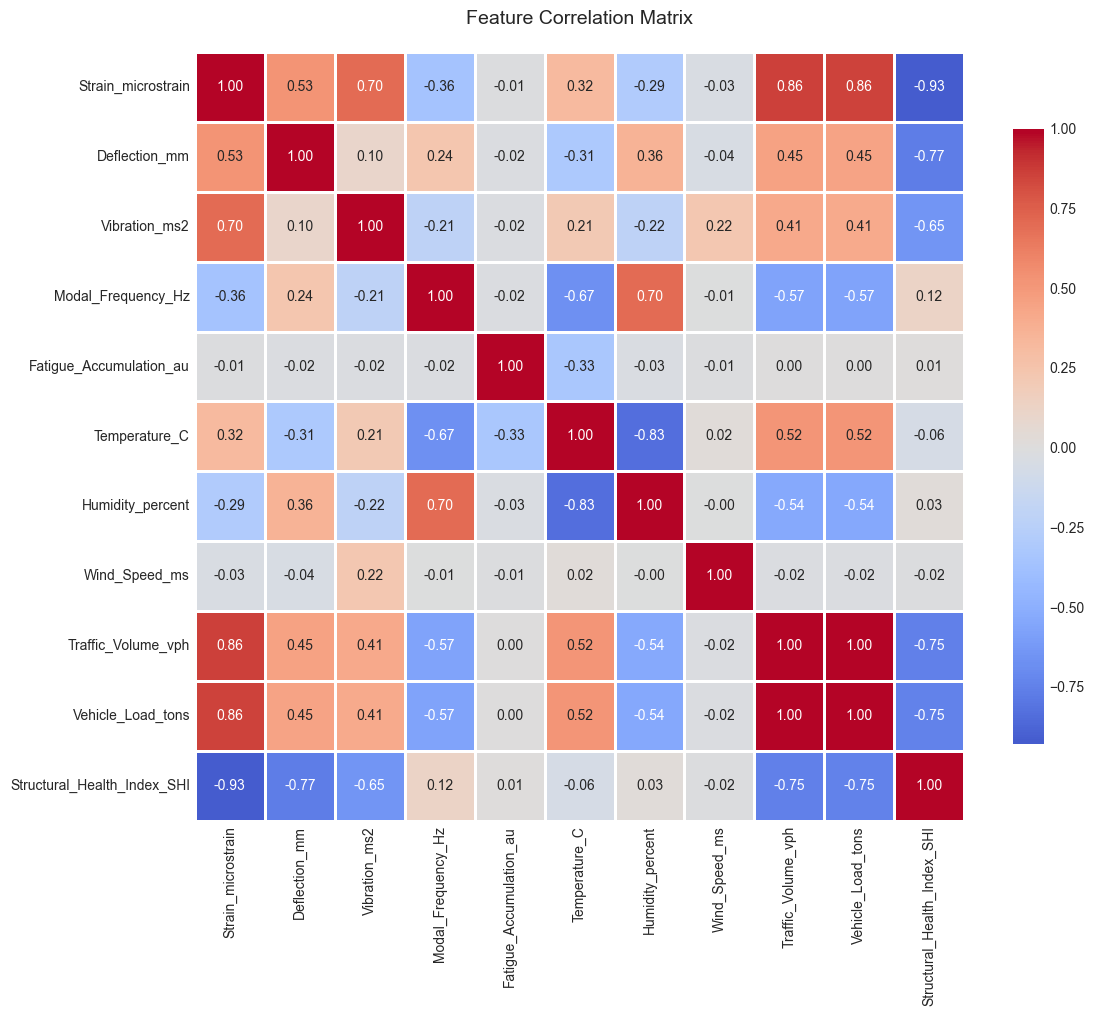


Top Correlations with SHI:
Modal_Frequency_Hz         0.120427
Humidity_percent           0.025454
Fatigue_Accumulation_au    0.006680
Wind_Speed_ms             -0.015691
Temperature_C             -0.055886
Vibration_ms2             -0.649747
Vehicle_Load_tons         -0.748023
Traffic_Volume_vph        -0.749549
Deflection_mm             -0.770731
Strain_microstrain        -0.929571
Name: Structural_Health_Index_SHI, dtype: float64


In [14]:
# ============================================
# 6. CORRELATION ANALYSIS
# ============================================
print_section("Correlation Analysis")


corr_Features = FEATURE_COLS + [TARGET_COL] 
corr_matrix = bridge_df[corr_Features].corr()

# Plot Heatmap

fig , ax = plt.subplots(figsize = (12,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='0.2f',
    cmap='coolwarm',
    center = 0,
    square=True,
    linewidths=1,
    cbar_kws={"shrink":0.8}
)
plt.title('Feature Correlation Matrix', fontsize=14, pad=20)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'eda_correlation_matrix.png'), dpi=FIGURE_DPI)
plt.show()

# Top correlations with SHI
shi_corr = corr_matrix[TARGET_COL].drop(TARGET_COL).sort_values(ascending=False)
print("\nTop Correlations with SHI:")
print(shi_corr)

In [ ]:
# Correlation patterns reveal how bridge health responds to different factors

# Strongest drivers of bridge health degradation:
# 1. Strain measurements (-0.93) - direct structural response
# 2. Deflection (-0.77) - bridge flexibility under load  
# 3. Vibration (-0.65) - dynamic response patterns

# Unexpected finding: Temperature and humidity don't directly impact SHI much
# (-0.06 and 0.03 correlations) - maybe they affect sensors more than structure

# Traffic patterns clearly stress the bridge:
# • Heavy vehicles and traffic volume both show -0.75 correlation with health
# • Strain jumps with traffic (0.86 correlation) - makes sense physically

# Modal frequency interesting: slight positive correlation (0.12)
# Higher vibration frequencies might indicate stiffer, healthier structure

# Fatigue accumulation shows almost zero correlation (0.01)
# Maybe it's a long-term factor not captured in this snapshot

# Practical takeaway: Monitor strain and deflection during rush hour
# Traffic management could directly extend bridge life

# Surprise: Weather factors (wind, temp, humidity) matter less than expected
# Bridge seems resilient to normal weather swings

# Red flag: Traffic volume and vehicle load perfectly correlated (1.00)
# These measure the same thing - use one to avoid model confusion

# Most useful sensors: strain gauges and deflection meters
# They give the clearest picture of structural health


  Time Series Analysis


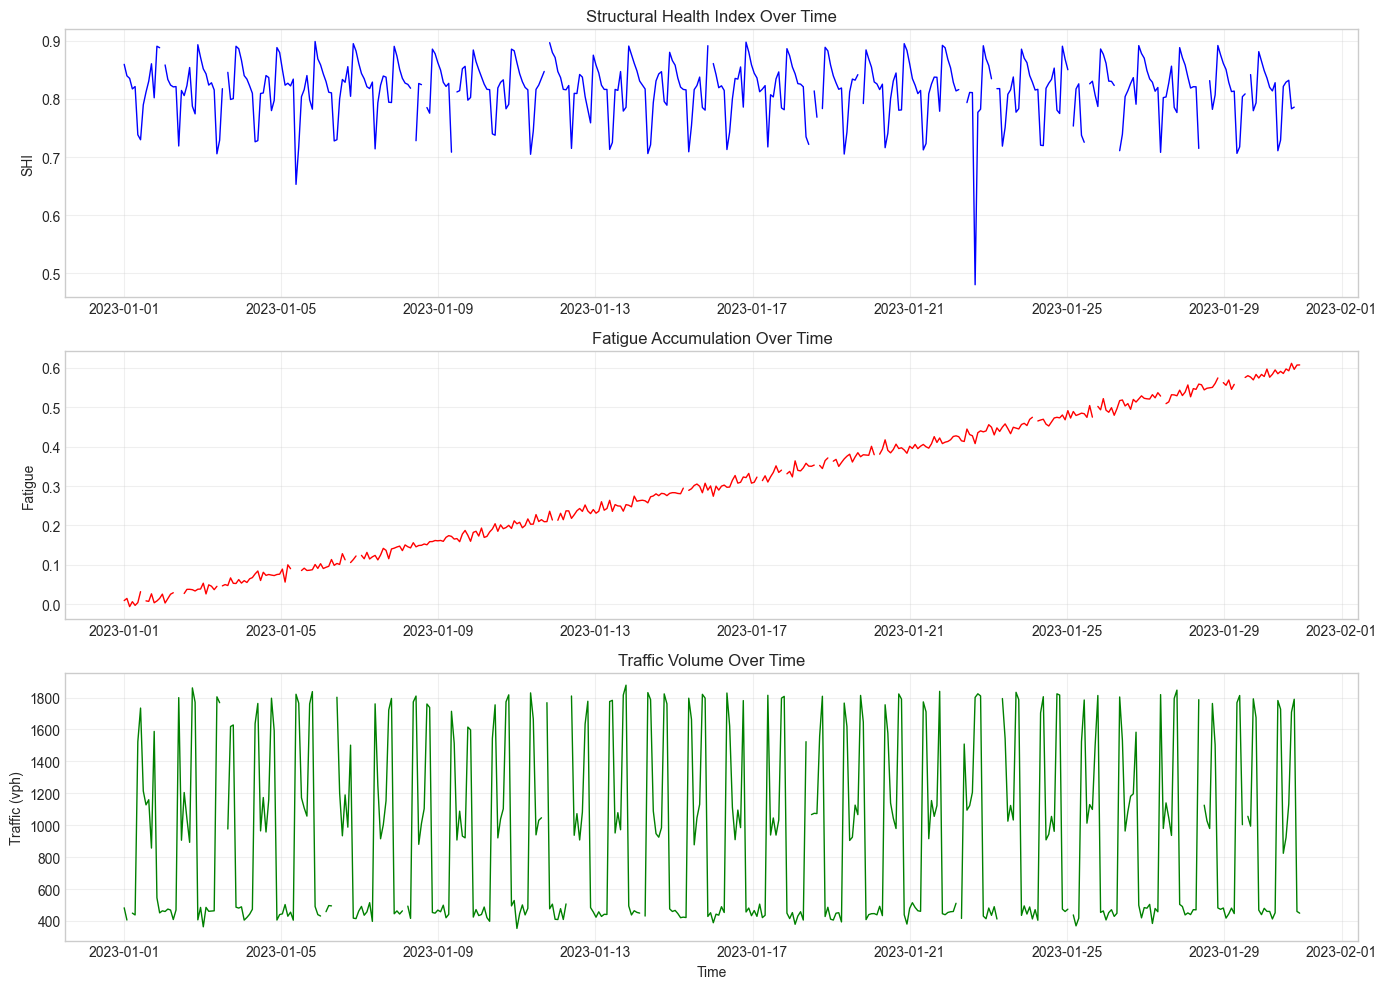

In [18]:
# ============================================
# 7. TIME SERIES PATTERNS
# ============================================
print_section("Time Series Analysis")

# Sample data for plotting (every 100th point)

df_sample = bridge_df[::100].copy()

fig , axes = plt.subplots(3,1, figsize = (14,10))

# SHI over time

axes[0].plot(df_sample['Timestamp'],df_sample[TARGET_COL], color = 'blue', linewidth = 1)
axes[0].set_ylabel('SHI', fontsize =10)
axes[0].set_title('Structural Health Index Over Time', fontsize = 12)
axes[0].grid(alpha=0.3)

# Fatigue over time
axes[1].plot(df_sample['Timestamp'],df_sample['Fatigue_Accumulation_au'], color = 'red', linewidth = 1)
axes[1].set_ylabel('Fatigue', fontsize =10)
axes[1].set_title('Fatigue Accumulation Over Time', fontsize = 12)
axes[1].grid(alpha=0.3)

# Traffic over time
axes[2].plot(df_sample['Timestamp'], df_sample['Traffic_Volume_vph'], color='green', linewidth=1)
axes[2].set_ylabel('Traffic (vph)', fontsize=10)
axes[2].set_xlabel('Time', fontsize=10)
axes[2].set_title('Traffic Volume Over Time', fontsize=12)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'eda_time_series.png'), dpi=FIGURE_DPI)
plt.show()



  Health Status Distribution

Health Status Distribution:
Health_Category
Excellent    30594
Good         10574
Poor          1888
Fair           144
Name: count, dtype: int64

Percentages:
Health_Category
Excellent    70.82
Good         24.48
Poor          4.37
Fair          0.33
Name: count, dtype: float64


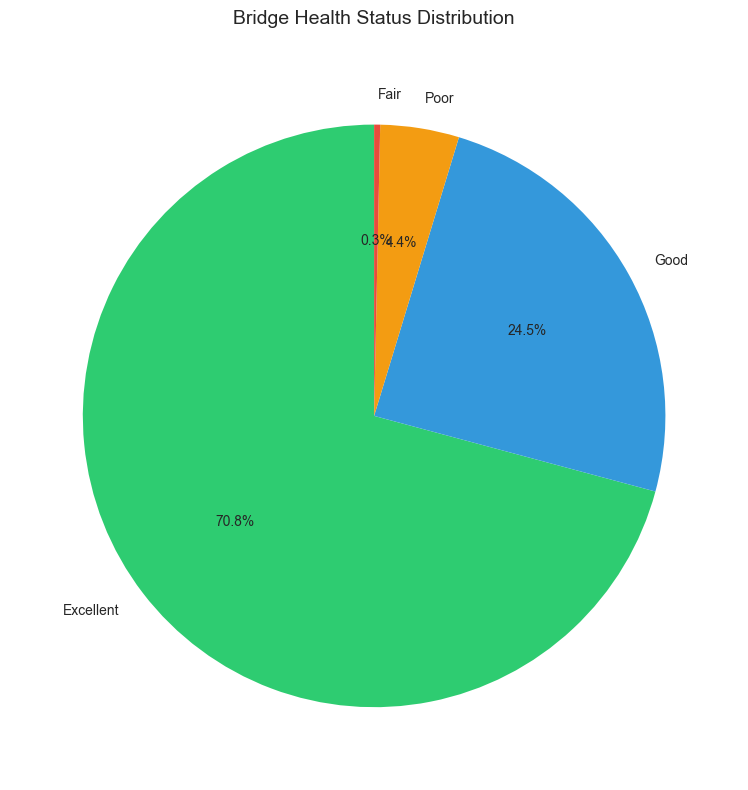

In [19]:
# ============================================
# 8. HEALTH STATUS CATEGORIES
# ============================================
print_section("Health Status Distribution")

# Define health categories based on SHI
def categorize_health(shi):
    if shi >= 0.8:
        return 'Excellent'
    elif shi >= 0.7:
        return 'Good'
    elif shi >= 0.6:
        return 'Fair'
    else:
        return 'Poor'

bridge_df['Health_Category'] = bridge_df[TARGET_COL].apply(categorize_health)

# Count distribution
health_counts = bridge_df['Health_Category'].value_counts()
print("\nHealth Status Distribution:")
print(health_counts)
print(f"\nPercentages:")
print((health_counts / len(bridge_df) * 100).round(2))

# Pie chart
fig, ax = plt.subplots(figsize=(8, 8))
colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']
ax.pie(
    health_counts.values,
    labels=health_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors
)
ax.set_title('Bridge Health Status Distribution', fontsize=14, pad=20)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'eda_health_categories.png'), dpi=FIGURE_DPI)
plt.show()
